<a href="https://colab.research.google.com/github/Henrique-Goncalves-Dev/Processament-de-imagem/blob/main/Portifolio_Imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True

PASTA_IMAGENS = Path('imagens')

def carregar_imagem(caminho):
    return np.asarray(Image.open(caminho).convert('RGB'), dtype=np.uint8)

def para_cinza(img_rgb):
    # Conversão RGB para luminância, mantendo a imagem entre 0 e 255.
    cinza = img_rgb[..., 0] * 0.299 + img_rgb[..., 1] * 0.587 + img_rgb[..., 2] * 0.114
    return np.rint(cinza).clip(0, 255).astype(np.uint8)

def calcHist(img):
    # Ideia da função usada no repositório: contar cada intensidade.
    hist_arr = np.zeros(256, dtype=int)
    for px in np.asarray(img, dtype=np.uint8).ravel():
        hist_arr[int(px)] += 1
    return hist_arr

def expandir_contraste(img, L, H):
    if L >= H:
        raise ValueError('É necessário que L seja menor que H.')
    resultado = (img.astype(float) - L) * 255 / (H - L)
    return np.rint(resultado).clip(0, 255).astype(np.uint8)

def equalizar(img):
    hist = calcHist(img)
    cdf = hist.cumsum()
    valores_presentes = np.flatnonzero(hist)
    if len(valores_presentes) == 0:
        return img.copy()
    cdf_min = cdf[valores_presentes[0]]
    denominador = img.size - cdf_min
    if denominador == 0:
        return img.copy()
    tabela = np.rint((cdf - cdf_min) * 255 / denominador).clip(0, 255).astype(np.uint8)
    return tabela[img]

def corrigir_gamma(img, gamma):
    if gamma <= 0:
        raise ValueError('Gamma deve ser maior que zero.')
    resultado = 255 * (img.astype(float) / 255) ** gamma
    return np.rint(resultado).clip(0, 255).astype(np.uint8)

def mostrar_antes_depois(original_rgb, original_cinza, corrigida, titulo_original, titulo_corrigida):
    hist_original = calcHist(original_cinza)
    hist_corrigida = calcHist(corrigida)
    fig, ax = plt.subplots(2, 2, figsize=(12, 8))

    ax[0, 0].imshow(original_rgb)
    ax[0, 0].set_title(titulo_original)
    ax[0, 0].axis('off')

    ax[0, 1].imshow(corrigida, cmap='gray', vmin=0, vmax=255)
    ax[0, 1].set_title(titulo_corrigida)
    ax[0, 1].axis('off')

    ax[1, 0].bar(range(256), hist_original, color='dimgray', width=1)
    ax[1, 0].set_title('Histograma antes')
    ax[1, 0].set_xlim(0, 255)
    ax[1, 0].set_xlabel('Intensidade')
    ax[1, 0].set_ylabel('Quantidade de pixels')

    ax[1, 1].bar(range(256), hist_corrigida, color='steelblue', width=1)
    ax[1, 1].set_title('Histograma depois')
    ax[1, 1].set_xlim(0, 255)
    ax[1, 1].set_xlabel('Intensidade')
    ax[1, 1].set_ylabel('Quantidade de pixels')

    plt.tight_layout()
    plt.show()

def imprimir_resumo(nome, img):
    percentis = np.percentile(img, [5, 50, 95])
    print(f'{nome}: mínimo={img.min()}, P5={percentis[0]:.0f}, mediana={percentis[1]:.0f}, P95={percentis[2]:.0f}, máximo={img.max()}, média={img.mean():.1f}')

## 1. Imagem escura — foto noturna

### Diagnóstico

O histograma está fortemente concentrado na faixa de 0 a aproximadamente 100, com uma cauda pequena para intensidades altas causada pelas lâmpadas do ambiente. Isso indica subexposição: a maior parte da cena está em sombras e os detalhes dos rostos ficam pouco visíveis.

### Operação escolhida

Foi escolhida a **correção de gamma**, com `γ = 0,45`. Como o gamma é menor que 1, as intensidades baixas são elevadas, clareando as sombras sem aplicar uma segunda operação à imagem.

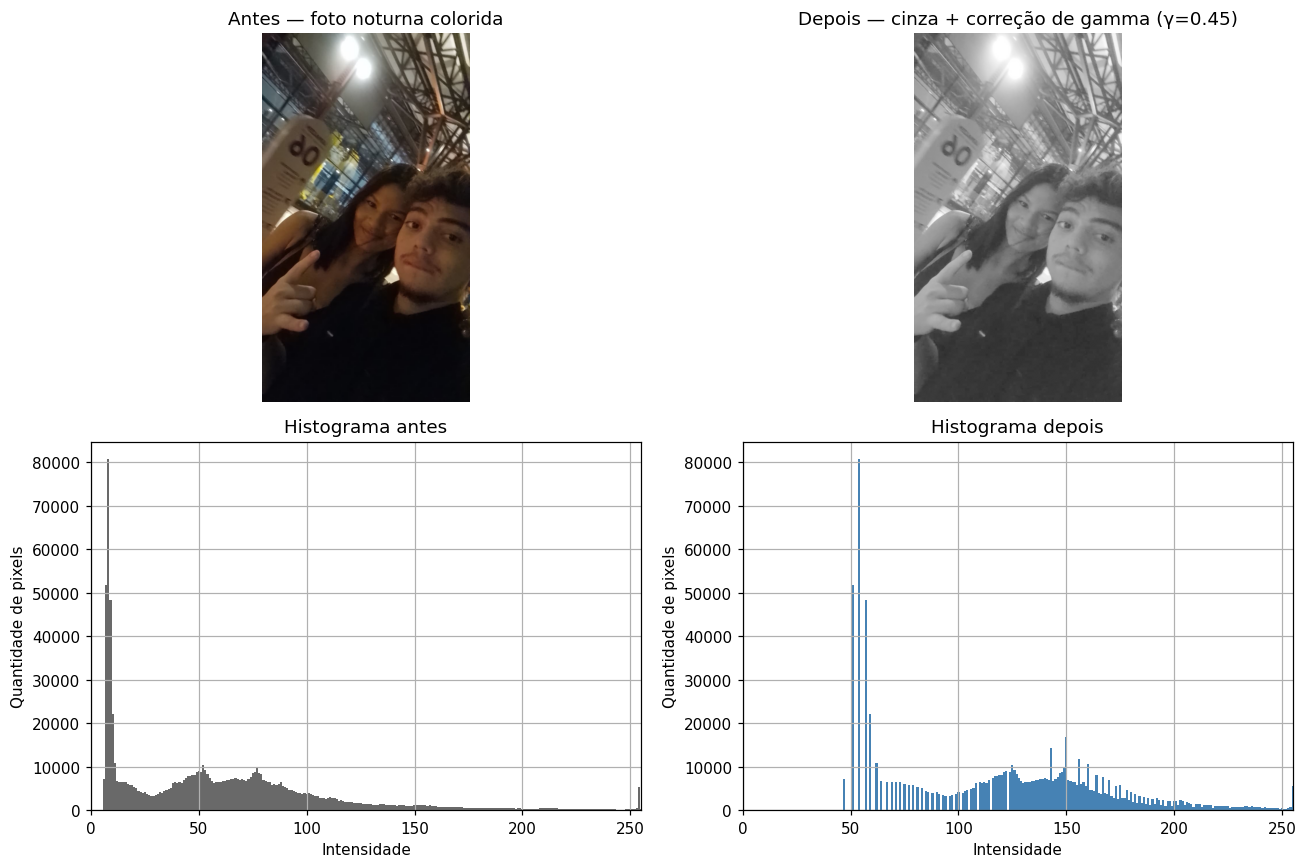

In [ ]:
gamma_escura = 0.45
img_escura_corrigida = corrigir_gamma(img_escura, gamma_escura)
mostrar_antes_depois(
    img_escura_rgb,
    img_escura,
    img_escura_corrigida,
    'Antes — foto noturna colorida',
    f'Depois — cinza + correção de gamma (γ={gamma_escura})'
)

## 2. Imagem clara demais — ambiente interno muito iluminado

### Diagnóstico

O histograma apresenta muitos pixels entre aproximadamente 100 e 220, além de uma presença relevante na região acima de 200. Isso mostra predominância de tons claros e indica que o ambiente e o fundo estão mais luminosos que o necessário, embora ainda existam detalhes nas regiões escuras.

### Operação escolhida

Foi escolhida a **correção de gamma**, com `γ = 1,4`. Como o gamma é maior que 1, os tons médios e claros são reduzidos, diminuindo a luminosidade geral e preservando melhor a diferença entre as regiões da foto.

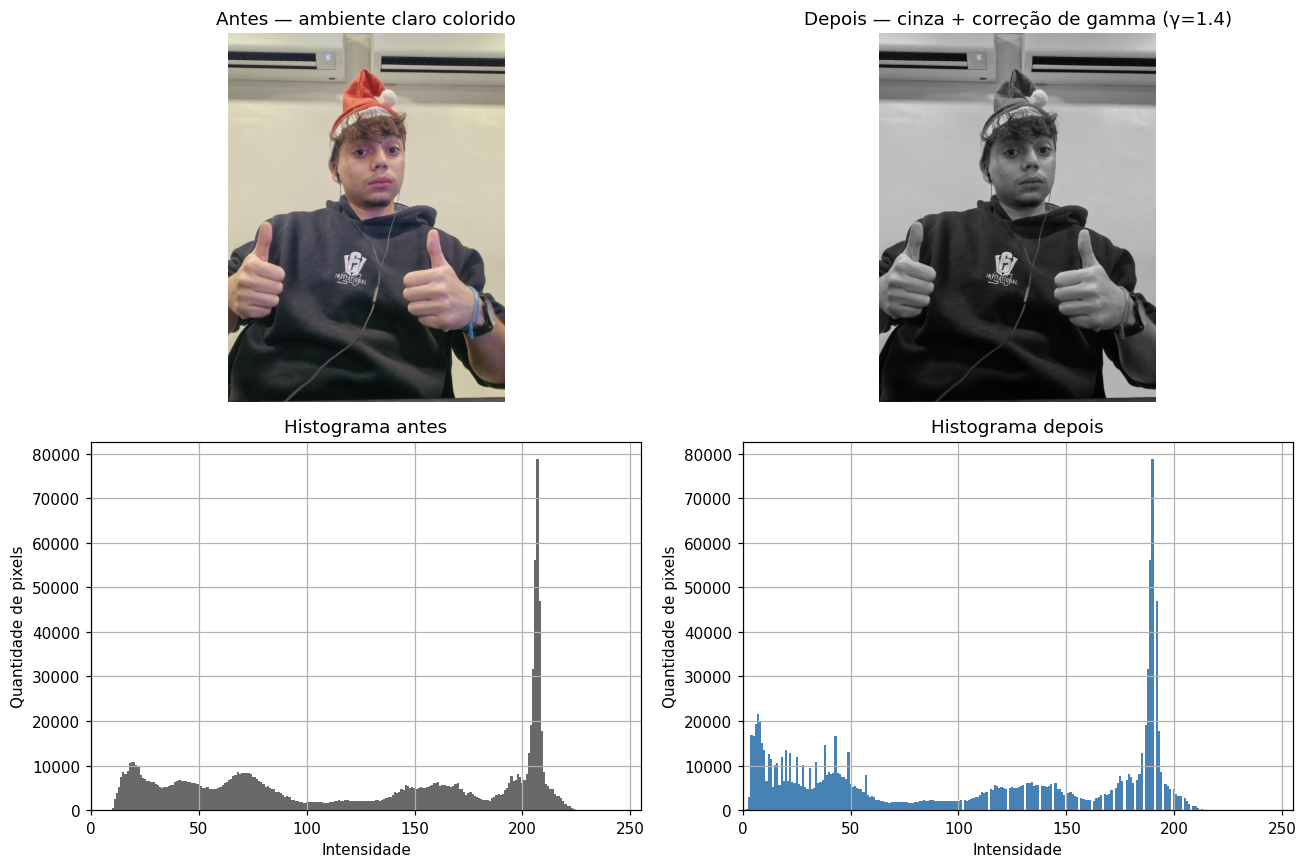

In [ ]:
gamma_clara = 1.4
img_clara_corrigida = corrigir_gamma(img_clara, gamma_clara)
mostrar_antes_depois(
    img_clara_rgb,
    img_clara,
    img_clara_corrigida,
    'Antes — ambiente claro colorido',
    f'Depois — cinza + correção de gamma (γ={gamma_clara})'
)

## 3. Imagem bem exposta — foto em grupo

### Diagnóstico

O histograma está espalhado por uma faixa ampla, indo das sombras até as altas luzes, sem concentração excessiva em 0 ou em 255. Essa distribuição indica uma exposição equilibrada, com detalhes visíveis tanto nas roupas escuras quanto nas faces e nas áreas iluminadas.

### Operação escolhida

Foi escolhida uma **expansão de contraste suave**, usando `L = 5` e `H = 250`. Como a imagem já está bem exposta e ocupa quase toda a faixa de intensidades, a expansão foi mantida pequena para aumentar levemente a separação entre sombras e altas luzes sem alterar muito a aparência original.

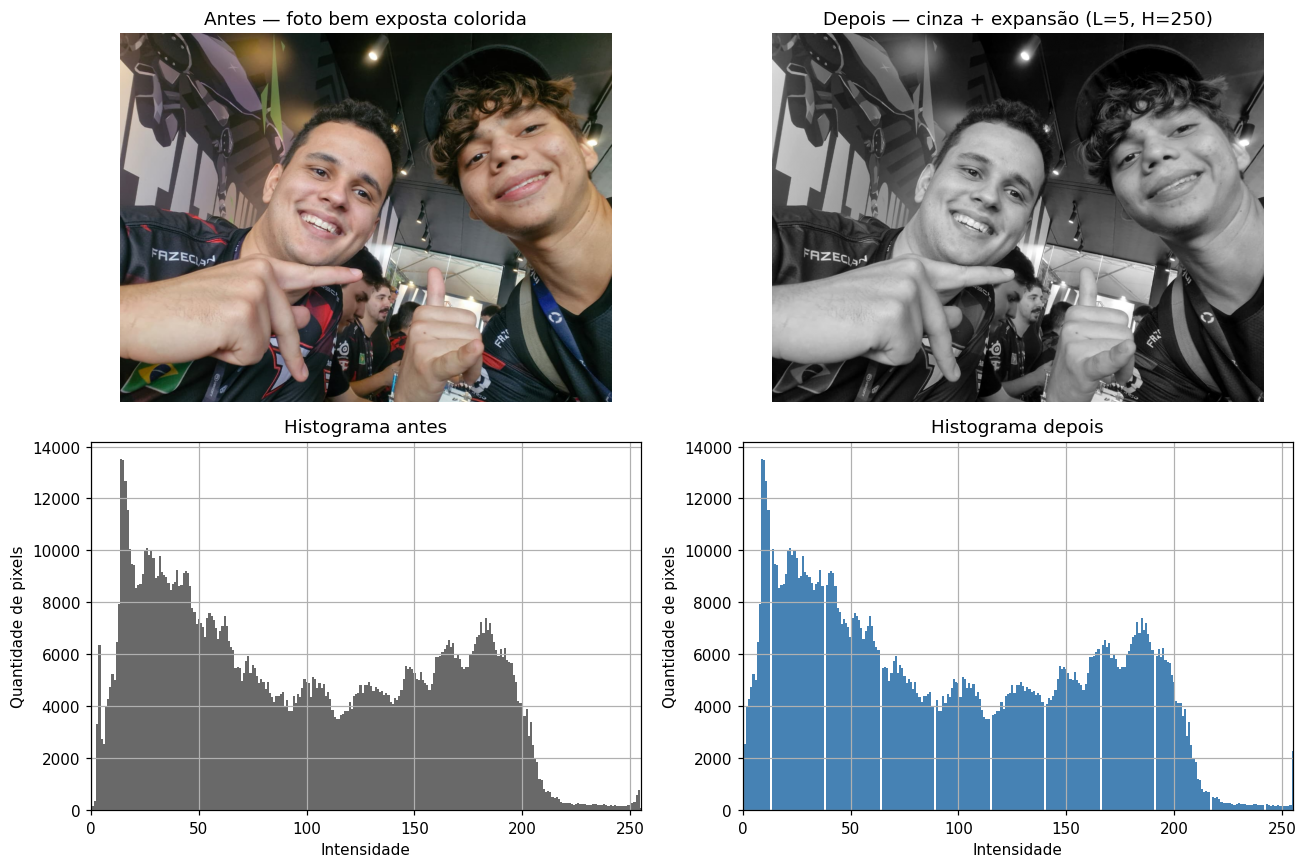

In [ ]:
L_bem = 5
H_bem = 250
img_bem_corrigida = expandir_contraste(img_bem, L_bem, H_bem)
mostrar_antes_depois(
    img_bem_rgb,
    img_bem,
    img_bem_corrigida,
    'Antes — foto bem exposta colorida',
    f'Depois — cinza + expansão (L={L_bem}, H={H_bem})'
)

## Comparação final das alterações

In [ ]:
def diferenca_media(img_original, img_corrigida):
    return np.mean(np.abs(img_corrigida.astype(float) - img_original.astype(float)))

print('Diferença média absoluta entre a imagem original e a corrigida:')
print(f'- Foto escura:       {diferenca_media(img_escura, img_escura_corrigida):.2f} níveis de intensidade')
print(f'- Foto clara demais: {diferenca_media(img_clara, img_clara_corrigida):.2f} níveis de intensidade')
print(f'- Foto bem exposta:  {diferenca_media(img_bem, img_bem_corrigida):.2f} níveis de intensidade')

Diferença média absoluta entre a imagem original e a corrigida:
- Foto escura:       60.80 níveis de intensidade
- Foto clara demais: 21.96 níveis de intensidade
- Foto bem exposta:  2.48 níveis de intensidade


## Resposta final

A operação que fez menos diferença foi a expansão de contraste aplicada à imagem bem exposta, com `L = 5` e `H = 250`. Isso aconteceu porque o histograma original já estava distribuído por uma faixa ampla e a exposição já era equilibrada; portanto, não havia uma deficiência forte de luminosidade ou contraste para corrigir, e a transformação suave produziu apenas uma alteração discreta.